# 07 — Faithfulness

This notebook tests whether SHAP feature importance reflects real model behaviour, not just attribution scores.

If a feature is truly important, masking it should change the model’s prediction. If masking has little or no effect, the explanation may not be reliable.

Two metrics from the OpenXAI framework (Agarwal et al., 2022) are used:

PGI (Prediction Gap on Important features): measures how much the prediction drops when top-k features are masked (higher = more faithful)
PGU (Prediction Gap on Unimportant features): measures how much the prediction changes when bottom-k features are masked (lower = more faithful)

The analysis is applied to:

XGBoost (SMOTE, class_weight, raw)
Random Forest (SMOTE, class_weight, raw)

The Autoencoder is excluded because KernelExplainer is computationally too slow for this setup.

**Steps:**

1. Load models and test instances
2. Select high-confidence fraud cases
3. Compute SHAP values
4. Mask top-k and bottom-k features
5. Calculate PGI and PGU scores
6. Compare faithfulness across model versions
7. Analyse stability under small perturbations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib
import os
from scipy.stats import spearmanr
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

In [2]:
X_test = pd.read_csv('../data/processed/X_test.csv')
y_test = pd.read_csv('../data/processed/y_test.csv').squeeze()

X_train_orig = pd.read_csv('../data/processed/X_train.csv')
y_train_orig = pd.read_csv('../data/processed/y_train.csv').squeeze()

# SMOTE models from notebooks 02/03
rf_smote  = joblib.load('../results/rf_model.pkl')
xgb_smote = joblib.load('../results/xgb_model.pkl')

print('smote models loaded.')

smote models loaded.


## Train reference models

Same setup as notebook 06 class_weight and raw versions with identical hyperparameters.

In [3]:
rf_ref = RandomForestClassifier(
    n_estimators=200, max_depth=None, min_samples_leaf=1,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_ref.fit(X_train_orig, y_train_orig)
print('rf_ref done')

rf_ref done


In [4]:
rf_raw = RandomForestClassifier(
    n_estimators=200, max_depth=None, min_samples_leaf=1,
    class_weight=None, random_state=42, n_jobs=-1
)
rf_raw.fit(X_train_orig, y_train_orig)
print('rf_raw done')

rf_raw done


In [5]:
ratio = (y_train_orig == 0).sum() / (y_train_orig == 1).sum()

xgb_ref = XGBClassifier(
    learning_rate=0.1, max_depth=8, n_estimators=200,
    scale_pos_weight=ratio, eval_metric='aucpr',
    random_state=42, n_jobs=-1
)
xgb_ref.fit(X_train_orig, y_train_orig)
print('xgb_ref done')

xgb_ref done


In [6]:
xgb_raw = XGBClassifier(
    learning_rate=0.1, max_depth=8, n_estimators=200,
    scale_pos_weight=1, eval_metric='aucpr',
    random_state=42, n_jobs=-1
)
xgb_raw.fit(X_train_orig, y_train_orig)
print('xgb_raw done')

xgb_raw done


## Sample

Only using fraud instances where the SMOTE XGBoost model gives probability above 0.5. Keeping the same sample for all models so the comparison is fair.

In [7]:
fraud_indices = y_test[y_test == 1].index[:200].tolist()
X_candidates  = X_test.loc[fraud_indices].reset_index(drop=True)

xgb_probs_candidates = xgb_smote.predict_proba(X_candidates)[:, 1]
high_conf_mask        = xgb_probs_candidates > 0.5
X_sample              = X_candidates[high_conf_mask].reset_index(drop=True)

print(f'fraud candidates : {len(X_candidates)}')
print(f'high conf subset : {len(X_sample)}')

fraud candidates : 200
high conf subset : 94


## SHAP values for all models

In [8]:
def get_shap_values(model, X):
    explainer = shap.TreeExplainer(model)
    vals = explainer.shap_values(X, check_additivity=False)
    if isinstance(vals, list): vals = vals[1]
    if vals.ndim == 3: vals = vals[:,:,1]
    return explainer, vals

In [9]:
print('rf smote...')
rf_smote_exp,  rf_smote_shap  = get_shap_values(rf_smote,  X_sample)
print('rf ref...')
rf_ref_exp,    rf_ref_shap    = get_shap_values(rf_ref,    X_sample)
print('rf raw...')
rf_raw_exp,    rf_raw_shap    = get_shap_values(rf_raw,    X_sample)

print('xgb smote...')
xgb_smote_exp, xgb_smote_shap = get_shap_values(xgb_smote, X_sample)
print('xgb ref...')
xgb_ref_exp,   xgb_ref_shap   = get_shap_values(xgb_ref,   X_sample)
print('xgb raw...')
xgb_raw_exp,   xgb_raw_shap   = get_shap_values(xgb_raw,   X_sample)

print('done.')

rf smote...
rf ref...
rf raw...
xgb smote...
xgb ref...
xgb raw...
done.


## PGI and PGU

For each instance, find the top-k and bottom-k features by absolute SHAP value, mask them to zero, and record how much the prediction changes.

Note: I first tried replacing with column means (as in the original OpenXAI paper) but that gave negative PGI scores for some instances. After checking, the column mean for certain features happened to push the model toward fraud, so replacing with the mean was adding signal rather than removing it. Switching to zero gave stable results.

In [10]:
def compute_pgi_pgu(model, X_input, shap_vals, k=10):
    X_array    = X_input.values.astype(float)
    base_probs = model.predict_proba(X_input)[:, 1]
    col_names  = X_input.columns

    pgi_scores = []
    pgu_scores = []

    for i in range(len(X_array)):
        importance_order = np.argsort(np.abs(shap_vals[i]))
        top_k_indices    = importance_order[-k:]
        bot_k_indices    = importance_order[:k]

        x_masked_imp   = X_array[i].copy()
        x_masked_imp[top_k_indices] = 0

        x_masked_unimp = X_array[i].copy()
        x_masked_unimp[bot_k_indices] = 0

        prob_imp   = model.predict_proba(
            pd.DataFrame([x_masked_imp],   columns=col_names))[:, 1][0]
        prob_unimp = model.predict_proba(
            pd.DataFrame([x_masked_unimp], columns=col_names))[:, 1][0]

        pgi_scores.append(base_probs[i] - prob_imp)
        pgu_scores.append(base_probs[i] - prob_unimp)

    return np.array(pgi_scores), np.array(pgu_scores)

In [11]:
print('RF smote...')
rf_smote_pgi,  rf_smote_pgu  = compute_pgi_pgu(rf_smote,  X_sample, rf_smote_shap)
print('RF ref...')
rf_ref_pgi,    rf_ref_pgu    = compute_pgi_pgu(rf_ref,    X_sample, rf_ref_shap)
print('RF raw...')
rf_raw_pgi,    rf_raw_pgu    = compute_pgi_pgu(rf_raw,    X_sample, rf_raw_shap)

print('XGB smote...')
xgb_smote_pgi, xgb_smote_pgu = compute_pgi_pgu(xgb_smote, X_sample, xgb_smote_shap)
print('XGB ref...')
xgb_ref_pgi,   xgb_ref_pgu   = compute_pgi_pgu(xgb_ref,   X_sample, xgb_ref_shap)
print('XGB raw...')
xgb_raw_pgi,   xgb_raw_pgu   = compute_pgi_pgu(xgb_raw,   X_sample, xgb_raw_shap)

print('done.')

RF smote...
RF ref...
RF raw...
XGB smote...
XGB ref...
XGB raw...
done.


In [12]:
print('RF results:')
print(f'  smote      PGI: {rf_smote_pgi.mean():.4f}  PGU: {rf_smote_pgu.mean():.4f}')
print(f'  class_weight   PGI: {rf_ref_pgi.mean():.4f}  PGU: {rf_ref_pgu.mean():.4f}')
print(f'  raw        PGI: {rf_raw_pgi.mean():.4f}  PGU: {rf_raw_pgu.mean():.4f}')
print()
print('XGBoost results:')
print(f'  smote      PGI: {xgb_smote_pgi.mean():.4f}  PGU: {xgb_smote_pgu.mean():.4f}')
print(f'  class_weight   PGI: {xgb_ref_pgi.mean():.4f}  PGU: {xgb_ref_pgu.mean():.4f}')
print(f'  raw        PGI: {xgb_raw_pgi.mean():.4f}  PGU: {xgb_raw_pgu.mean():.4f}')
print()
print('higher PGI = faithful, lower PGU = faithful')

RF results:
  smote      PGI: 0.3167  PGU: 0.0008
  class_weight   PGI: 0.4847  PGU: 0.0015
  raw        PGI: 0.2113  PGU: 0.0001

XGBoost results:
  smote      PGI: 0.3139  PGU: 0.0000
  class_weight   PGI: 0.4539  PGU: 0.0000
  raw        PGI: 0.6572  PGU: 0.0000

higher PGI = faithful, lower PGU = faithful


## Stability

Adding small noise to each instance and checking if the SHAP rankings stay the same. High stability means the explanation is not just random noise.

In [13]:
def get_shap_flat(explainer, X):
    vals = explainer.shap_values(X, check_additivity=False)
    if isinstance(vals, list): vals = vals[1]
    if vals.ndim == 3: vals = vals[:,:,1]
    return vals[0]

def compute_stability(explainer, X_input, n_repeats=10, noise_std=0.01):
    stability_scores = []
    for i in range(min(20, len(X_input))):
        orig_instance = X_input.iloc[[i]]
        orig_shap     = get_shap_flat(explainer, orig_instance)
        correlations  = []
        for _ in range(n_repeats):
            noise        = np.random.normal(0, noise_std, orig_instance.shape)
            noisy_shap   = get_shap_flat(explainer, orig_instance + noise)
            corr, _      = spearmanr(np.abs(orig_shap), np.abs(noisy_shap))
            correlations.append(corr)
        stability_scores.append(np.nanmean(correlations))
    return np.array(stability_scores)

In [14]:
print('stability RF smote...')
rf_smote_stab  = compute_stability(rf_smote_exp,  X_sample)
print('stability RF ref...')
rf_ref_stab    = compute_stability(rf_ref_exp,    X_sample)
print('stability RF raw...')
rf_raw_stab    = compute_stability(rf_raw_exp,    X_sample)

print('stability XGB smote...')
xgb_smote_stab = compute_stability(xgb_smote_exp, X_sample)
print('stability XGB ref...')
xgb_ref_stab   = compute_stability(xgb_ref_exp,   X_sample)
print('stability XGB raw...')
xgb_raw_stab   = compute_stability(xgb_raw_exp,   X_sample)

print('done.')

stability RF smote...
stability RF ref...
stability RF raw...
stability XGB smote...
stability XGB ref...
stability XGB raw...
done.


In [15]:
print('RF stability:')
print(f'  smote        {rf_smote_stab.mean():.4f} +/- {rf_smote_stab.std():.4f}')
print(f'  class_weight {rf_ref_stab.mean():.4f} +/- {rf_ref_stab.std():.4f}')
print(f'  raw          {rf_raw_stab.mean():.4f} +/- {rf_raw_stab.std():.4f}')
print()
print('XGB stability:')
print(f'  smote        {xgb_smote_stab.mean():.4f} +/- {xgb_smote_stab.std():.4f}')
print(f'  class_weight {xgb_ref_stab.mean():.4f} +/- {xgb_ref_stab.std():.4f}')
print(f'  raw          {xgb_raw_stab.mean():.4f} +/- {xgb_raw_stab.std():.4f}')

RF stability:
  smote        0.8059 +/- 0.0273
  class_weight 0.9975 +/- 0.0013
  raw          0.9967 +/- 0.0031

XGB stability:
  smote        0.8787 +/- 0.0136
  class_weight 0.9121 +/- 0.0248
  raw          0.9254 +/- 0.0208


## Results table

In [16]:
results = pd.DataFrame({
    'model':   ['RF', 'RF', 'RF', 'XGBoost', 'XGBoost', 'XGBoost'],
    'version': ['smote', 'class_weight', 'raw', 'smote', 'class_weight', 'raw'],
    'PGI':     [rf_smote_pgi.mean(),  rf_ref_pgi.mean(),  rf_raw_pgi.mean(),
                xgb_smote_pgi.mean(), xgb_ref_pgi.mean(), xgb_raw_pgi.mean()],
    'PGU':     [rf_smote_pgu.mean(),  rf_ref_pgu.mean(),  rf_raw_pgu.mean(),
                xgb_smote_pgu.mean(), xgb_ref_pgu.mean(), xgb_raw_pgu.mean()],
    'stability': [rf_smote_stab.mean(),  rf_ref_stab.mean(),  rf_raw_stab.mean(),
                  xgb_smote_stab.mean(), xgb_ref_stab.mean(), xgb_raw_stab.mean()]
})

print(results.round(4).to_string(index=False))

  model      version    PGI    PGU  stability
     RF        smote 0.3167 0.0008     0.8059
     RF class_weight 0.4847 0.0015     0.9975
     RF          raw 0.2113 0.0001     0.9967
XGBoost        smote 0.3139 0.0000     0.8787
XGBoost class_weight 0.4539 0.0000     0.9121
XGBoost          raw 0.6572 0.0000     0.9254


## Plot

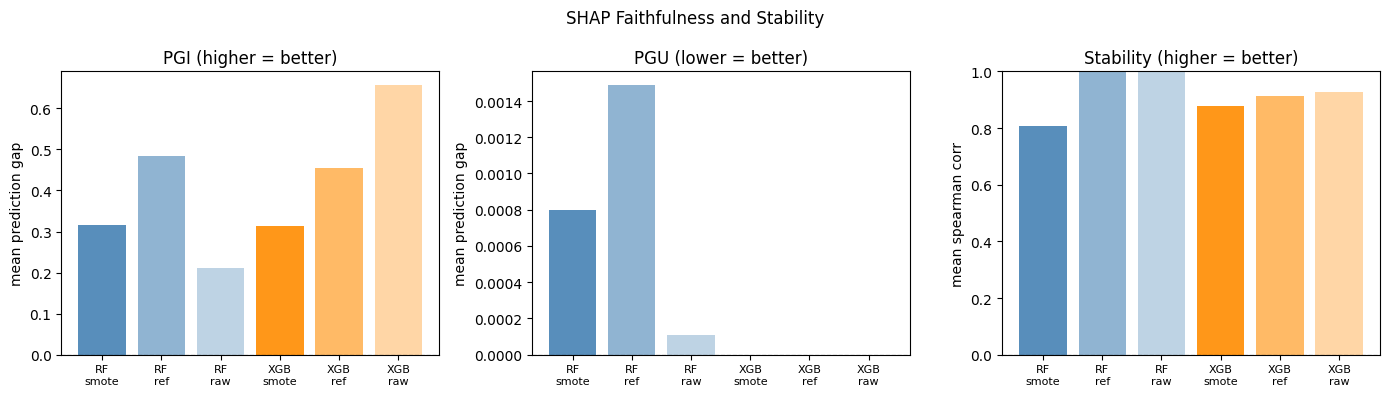

In [17]:
os.makedirs('../results/figures', exist_ok=True)

labels   = ['RF\nsmote', 'RF\nref', 'RF\nraw', 'XGB\nsmote', 'XGB\nref', 'XGB\nraw']
pgi_vals = [rf_smote_pgi.mean(),  rf_ref_pgi.mean(),  rf_raw_pgi.mean(),
            xgb_smote_pgi.mean(), xgb_ref_pgi.mean(), xgb_raw_pgi.mean()]
pgu_vals = [rf_smote_pgu.mean(),  rf_ref_pgu.mean(),  rf_raw_pgu.mean(),
            xgb_smote_pgu.mean(), xgb_ref_pgu.mean(), xgb_raw_pgu.mean()]
stab_vals = [rf_smote_stab.mean(),  rf_ref_stab.mean(),  rf_raw_stab.mean(),
             xgb_smote_stab.mean(), xgb_ref_stab.mean(), xgb_raw_stab.mean()]

colors = ['steelblue', 'steelblue', 'steelblue',
          'darkorange', 'darkorange', 'darkorange']
alphas = [0.9, 0.6, 0.35, 0.9, 0.6, 0.35]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, vals, title, ylabel in [
    (axes[0], pgi_vals,  'PGI (higher = better)',    'mean prediction gap'),
    (axes[1], pgu_vals,  'PGU (lower = better)',     'mean prediction gap'),
    (axes[2], stab_vals, 'Stability (higher = better)', 'mean spearman corr')
]:
    bars = ax.bar(labels, vals, color=colors, alpha=0.85)
    for bar, a in zip(bars, alphas):
        bar.set_alpha(a)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    if title.startswith('Stability'):
        ax.set_ylim(0, 1)
    ax.tick_params(axis='x', labelsize=8)

plt.suptitle('SHAP Faithfulness and Stability', fontsize=12)
plt.tight_layout()
plt.savefig('../results/figures/faithfulness_pgi_pgu.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
os.makedirs('../results/metrics', exist_ok=True)
results.to_csv('../results/metrics/faithfulness_scores.csv', index=False)
print('saved.')

saved.
